/home/a-ldungl/miniconda3/envs/qc/lib/python3.11/site-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


optimization_level=0:


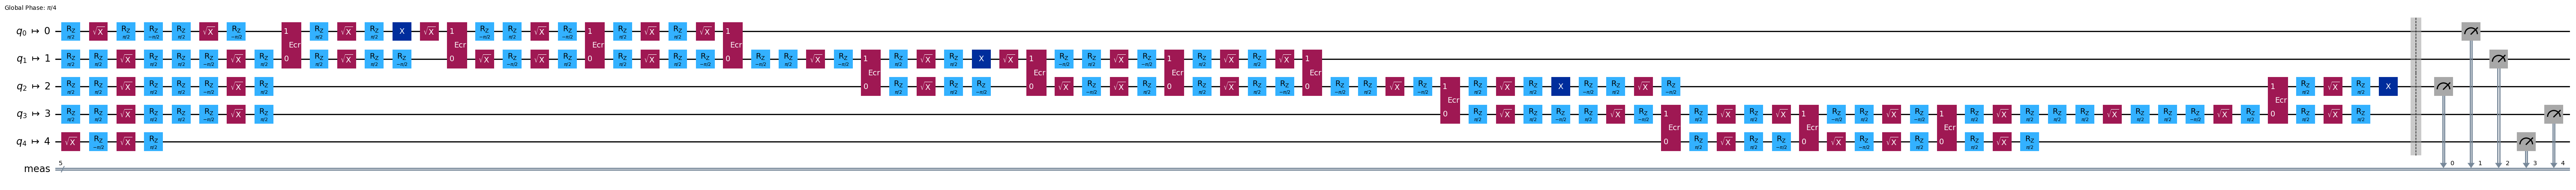

optimization_level=2:


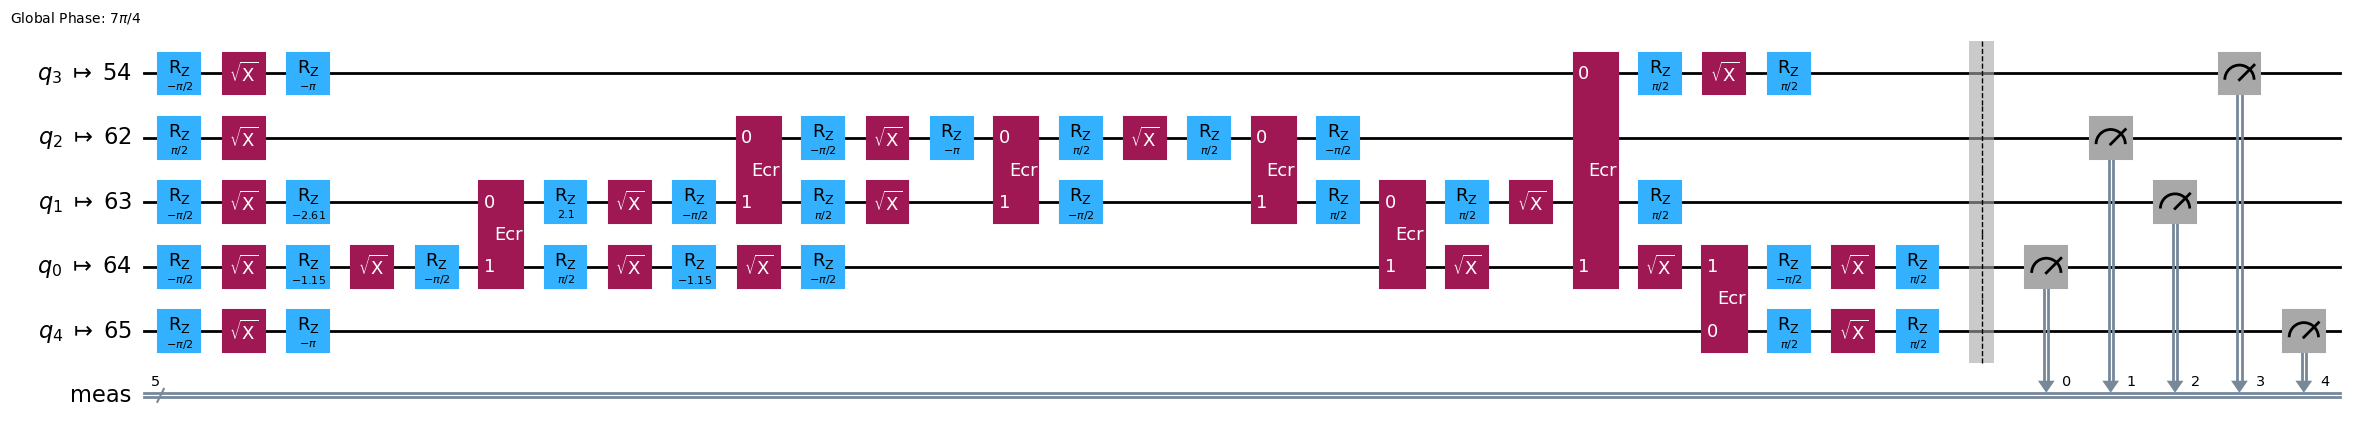

In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.primitives import BackendSamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeBrisbane

backend = FakeBrisbane()

num_qubits = 5

ghz_circ = QuantumCircuit(num_qubits)
ghz_circ.h(0)
[ghz_circ.cx(0, i) for i in range(1, num_qubits)]
ghz_circ.measure_all()
ghz_circ.draw("mpl")

pm0 = generate_preset_pass_manager(
    optimization_level=0, backend=backend, seed_transpiler=777
)
pm2 = generate_preset_pass_manager(
    optimization_level=2, backend=backend, seed_transpiler=777
)
circ0 = pm0.run(ghz_circ)
circ2 = pm2.run(ghz_circ)
print("optimization_level=0:")
display(circ0.draw("mpl", idle_wires=False, fold=-1))
print("optimization_level=2:")
display(circ2.draw("mpl", idle_wires=False, fold=-1))

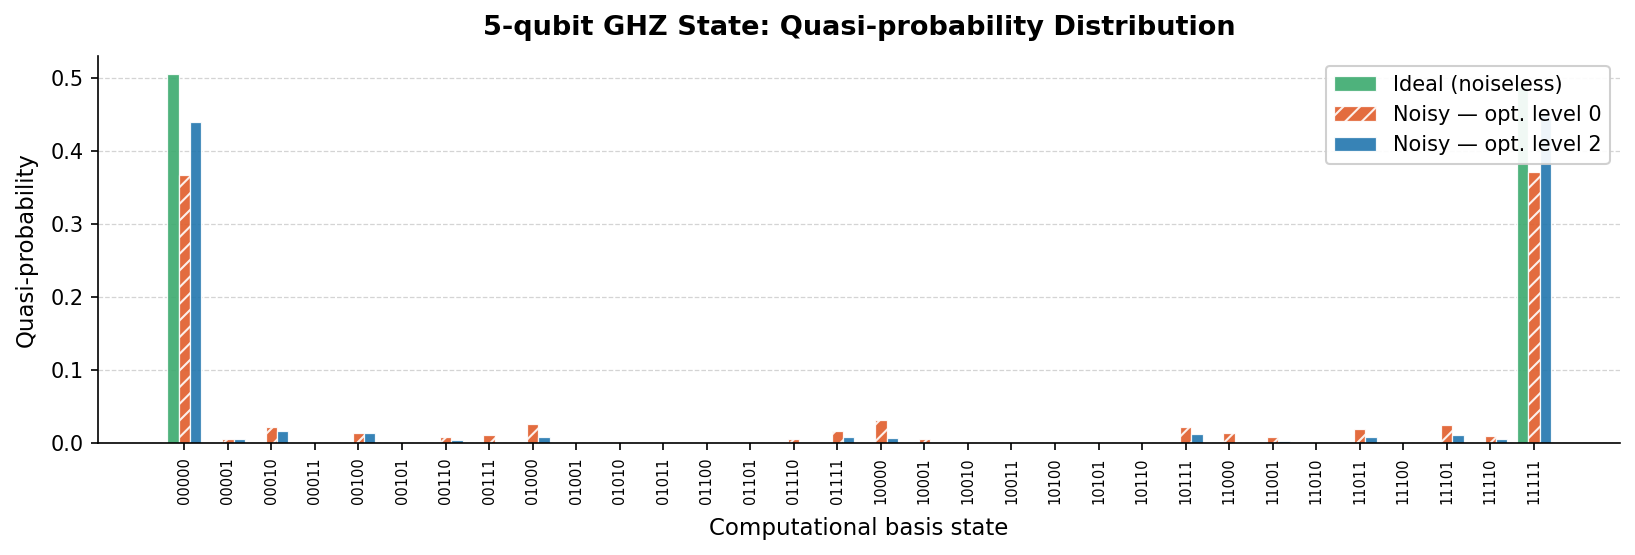

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from qiskit.primitives import StatevectorSampler

# ── Locate project root & shared utilities ────────────────────────────────────
_cwd = Path(os.getcwd())
_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / "src").exists() and (p / "conf").exists()),
    None,
)
if _ROOT and str(_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(_ROOT / "notebooks"))

from shared.evaluation_artifacts import save_figure  # noqa: E402

ARTIFACT_DIR = _ROOT / "reports" / "noise-awareness"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# ── Matplotlib style (AGENT.md) ───────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlepad":     10,
    "axes.labelsize":    11,
    "axes.labelpad":     6,
    "axes.grid":         True,
    "grid.linestyle":    "--",
    "grid.linewidth":    0.6,
    "grid.alpha":        0.5,
    "grid.color":        "#AAAAAA",
    "axes.axisbelow":    True,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
    "legend.framealpha": 0.92,
    "legend.edgecolor":  "#CCCCCC",
    "lines.linewidth":   2.0,
    "lines.markersize":  6,
    "font.family":       "sans-serif",
})

# ── Simulate ──────────────────────────────────────────────────────────────────
SHOTS = 20_000

# Ideal: noiseless statevector simulation (ghz_circ has measure_all())
ideal_counts = (
    StatevectorSampler()
    .run([ghz_circ], shots=SHOTS)
    .result()[0].data.meas.get_counts()
)

# Noisy: FakeBrisbane hardware model, two optimization levels
_noisy = Sampler(backend=backend)
counts0 = _noisy.run([circ0], shots=SHOTS).result()[0].data.meas.get_counts()
counts2 = _noisy.run([circ2], shots=SHOTS).result()[0].data.meas.get_counts()

# ── Probability vectors over all 2^n basis states ────────────────────────────
all_states = [format(i, f"0{num_qubits}b") for i in range(2 ** num_qubits)]

def to_probs(counts):
    return np.array([counts.get(s, 0) / SHOTS for s in all_states])

ideal_probs = to_probs(ideal_counts)
probs0      = to_probs(counts0)
probs2      = to_probs(counts2)

# ── Plot ──────────────────────────────────────────────────────────────────────
# Colour & hatch per AGENT.md: primary=opt2, secondary=opt0, tertiary=ideal
# Hatch: unoptimized = "///" (distinguishable in greyscale), optimized = solid
COLORS = {"ideal": "#3BAA6E", "opt0": "#E05C2A", "opt2": "#2176AE"}

x = np.arange(len(all_states))
w = 0.26

fig, ax = plt.subplots(figsize=(11, 3.8))

ax.bar(x - w, ideal_probs, w,
       label="Ideal (noiseless)",    color=COLORS["ideal"],               alpha=0.90, edgecolor="white", linewidth=0.6)
ax.bar(x,     probs0,      w,
       label="Noisy — opt. level 0", color=COLORS["opt0"], hatch="///",   alpha=0.90, edgecolor="white", linewidth=0.6)
ax.bar(x + w, probs2,      w,
       label="Noisy — opt. level 2", color=COLORS["opt2"],                alpha=0.90, edgecolor="white", linewidth=0.6)

ax.set_title(f"{num_qubits}-qubit GHZ State: Quasi-probability Distribution")
ax.set_xlabel("Computational basis state")
ax.set_ylabel("Quasi-probability")
ax.set_xticks(x)
ax.set_xticklabels(all_states, rotation=90, fontsize=7)
ax.legend(loc="upper right")

# Bar charts: horizontal grid only (AGENT.md)
ax.yaxis.grid(True)
ax.xaxis.grid(False)

fig.tight_layout()
save_figure(fig, ARTIFACT_DIR / "ghz_quasi_probability.png")
plt.show()
